## Regularization in Logistic Regression

In this notebook we will see the application of various regularization methods (like: L1, L2, and ElasticNet) applied to Logistic Regression and compare their performances along with Unregularized Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

### Create synthetic classification dataset

We will create a synthetic dataset for this notebook using the `make_classification` method in `sklearn.datasets`. 

This synthetic dataset will contain
- Total 6 features 
- Out of which 3 features are informative and 1 feature is redundant and rest 2 features are 'useless' feature or 'noise'
- Target is binary (0 or 1)


In [ ]:
X, y = make_classification(n_samples=1000,          # number of data points in the dataset
                           n_features=6,            # number of features / independent variables
                           n_classes=2,             # number of classes in the dataset
                           n_clusters_per_class=1,  # number of cluster in each class
                           n_informative=3,         # number of informative features
                           n_redundant=1,           # number of redundant features
                           n_repeated=0,            # number of repeated features
                           class_sep=1.2,           # Larger values spread out the clusters/classes.
                           shuffle=True)            # whether to shuffle the dataset

In [3]:
feature_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

dataset = pd.DataFrame(np.hstack((X, y.reshape(-1,1))), columns= feature_names + ['target'])

dataset.head(10)

,x1,x2,x3,x4,x5,x6,target
0,-1.895863,0.430729,-0.694074,-1.260270,1.522867,0.750522,0.0
1,-1.084050,0.177052,0.448874,-0.249039,0.346627,-0.479865,1.0
2,-1.537078,-0.228707,-1.479580,1.411947,-0.606528,-2.200746,1.0
3,-4.256560,-0.636736,-0.377801,1.174727,0.446778,2.633067,0.0
4,-1.444037,-0.551376,0.739826,1.978411,0.934973,-1.269951,1.0
5,0.528091,0.016241,-0.169829,-0.179996,1.336051,0.317628,1.0
6,-1.380244,1.581884,1.122649,-3.800915,0.276743,-1.103923,0.0
7,-0.708452,-0.717828,0.568368,2.025847,1.662069,-0.162710,1.0
8,-2.436227,-0.694047,0.432037,3.291390,-2.238407,-4.009861,1.0
9,-0.745671,-0.330970,0.554352,1.133494,-1.560794,-0.617015,1.0


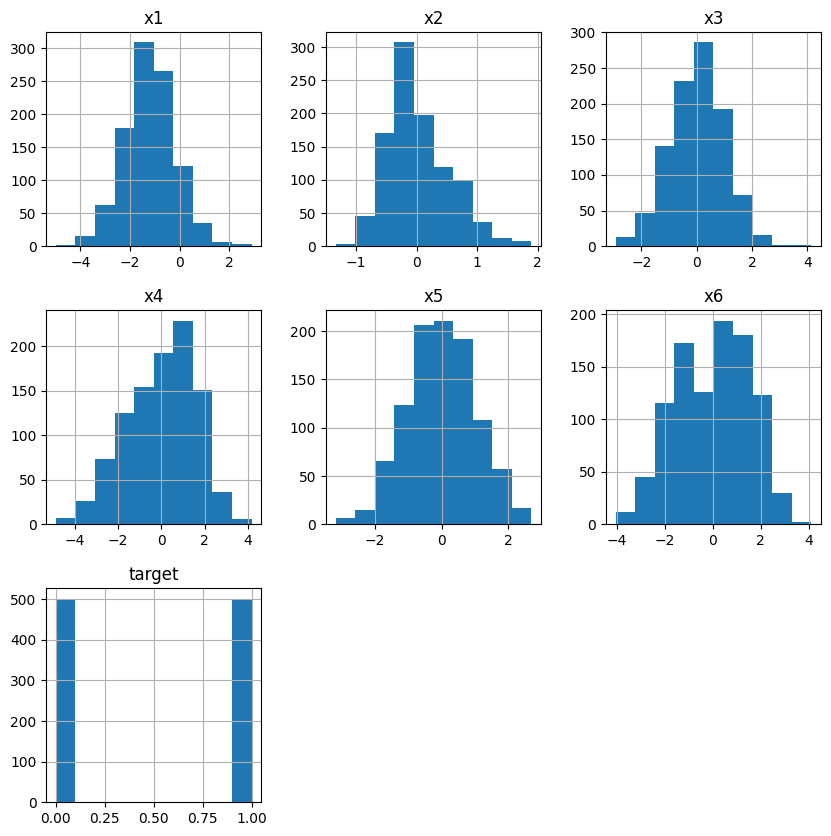

In [4]:
dataset.hist(figsize=(10,10));

#### Scatter plot of the data taking two features at a time

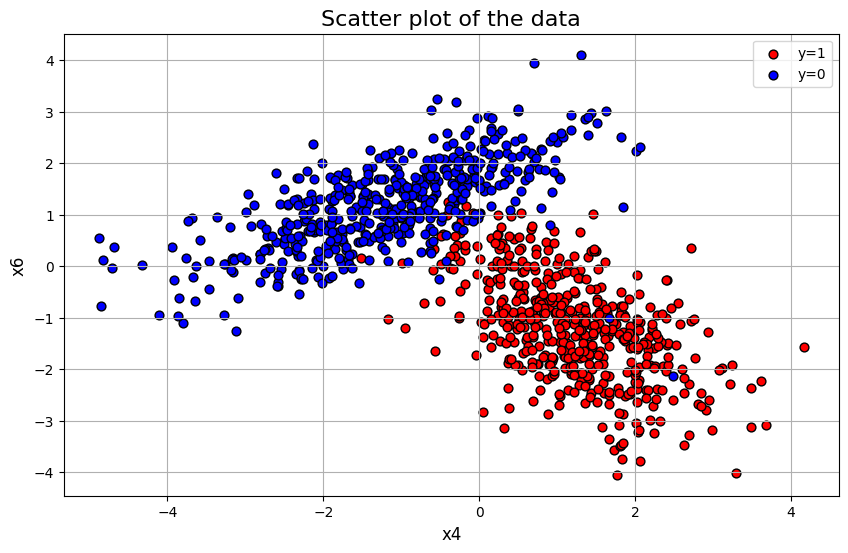

In [5]:
plt.figure(figsize=(10,6))
data_1 = dataset[dataset['target']==1]
data_0 = dataset[dataset['target']==0]

feature1 = 'x4'
feature2 = 'x6'
plt.scatter(x=data_1[feature1].values, y=data_1[feature2].values, s=40, c='r', edgecolor='k', label="y=1")
plt.scatter(x=data_0[feature1].values, y=data_0[feature2].values, s=40, c='b', edgecolor='k', label="y=0")
plt.title("Scatter plot of the data",fontsize=16)
plt.xlabel(f"{feature1}", fontsize=12)
plt.ylabel(f"{feature2}", fontsize=12)
plt.grid()
plt.legend()
plt.show()

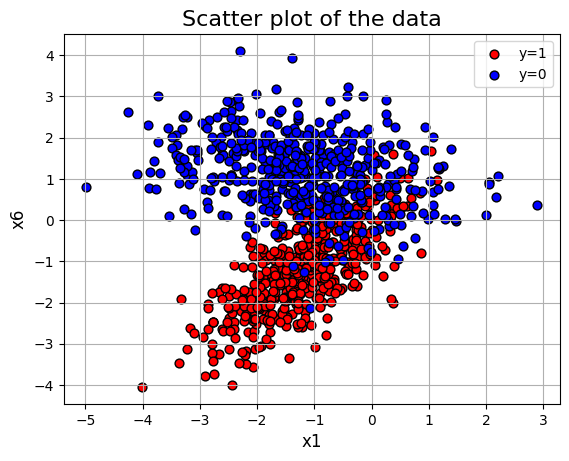

In [11]:
feature1 = 'x1'
feature2 = 'x6'
plt.scatter(x=data_1[feature1].values, y=data_1[feature2].values, s=40, c='r', edgecolor='k', label="y=1")
plt.scatter(x=data_0[feature1].values, y=data_0[feature2].values, s=40, c='b', edgecolor='k', label="y=0")
plt.title("Scatter plot of the data",fontsize=16)
plt.xlabel(f"{feature1}", fontsize=12)
plt.ylabel(f"{feature2}", fontsize=12)
plt.grid()
plt.legend()
plt.show()

### Feature transformation

First we will split the data into train and test and then perform `MinMaxScaler()` on all the numerical features. [We can also use `StandardScaler()`]

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

(800, 6) (200, 6)


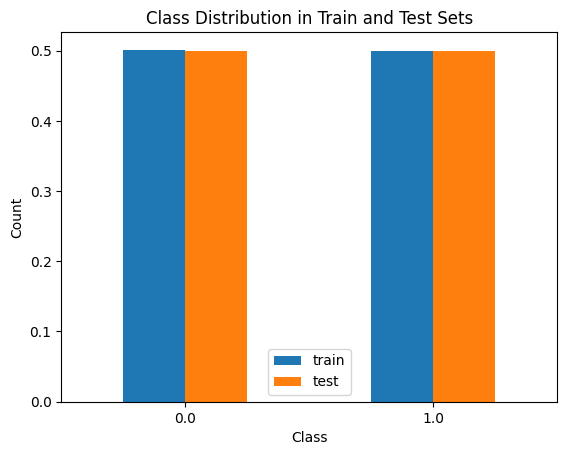

In [13]:
X = dataset.drop('target', axis=1)
y = dataset['target'].values.flatten()

# Create train/test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=123, test_size=0.2, stratify=y    # startified based on target variable, so that the distribution of the target variable is same in train and test dataset
)

print(X_train.shape, X_test.shape)

# Check the distribution of target variable in train and test dataset 
# This is to check the distribution of target variable is similar

pd.DataFrame({'train': pd.Series(y_train).value_counts(normalize=True),
              'test': pd.Series(y_test).value_counts(normalize=True)}).plot(kind='bar')
plt.title('Class Distribution in Train and Test Sets')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [14]:
numerical_cols = feature_names

preprocessor = ColumnTransformer(
    transformers=[
        ("min-max-scaling", MinMaxScaler(), numerical_cols)    # apply min-max scaling to the numerical columns
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('min-max-scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``"

In [15]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

X_train[0]

array([0.38294462, 0.37144099, 0.31104529, 0.53277433, 0.31341014,
       0.71405428])

### Modelling

In this notebook our objective is to 

- See how the unregularized logistic regression performs on the test-dataset and compute the absolute values of the coefficients (model weights) of unregularized logistic regression.
- Then apply L2, L1, and ElasticNet regularization one by one and observe the model performance in each cases. We will also compute the absolute values of the coefficients (model weights) of different methods.
- Finally we will compare the coefficients of different methods.

### Unregularized Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [17]:
# defining the model
lr_unreg = LogisticRegression(penalty=None, max_iter=1000)

# fitting / training the model
lr_unreg.fit(X_train, y_train)

# predicting on test dataset
y_pred_test = lr_unreg.predict(X_test)

c:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
# Performance on test dataset

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       100
         1.0       0.99      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



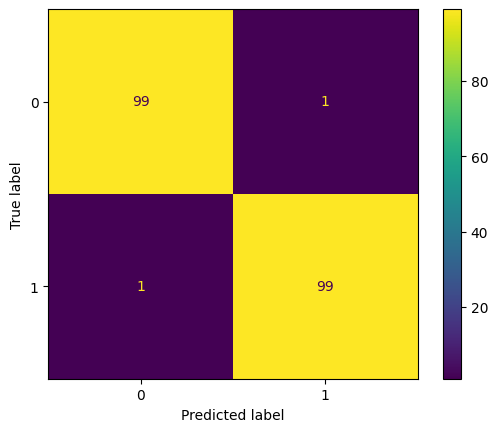

In [19]:
cm_test = confusion_matrix(y_test, y_pred_test)

ConfusionMatrixDisplay(cm_test).plot();

In [20]:
# Coefficients / model weights / parameters

coefficients_unreg = [abs(x.item()) for x in lr_unreg.coef_.flatten()]

coefficient_dict_unreg = dict(zip(feature_names, coefficients_unreg))

coefficient_dict_unreg_sorted = dict(sorted(coefficient_dict_unreg.items(), key=lambda item: item[1], reverse=True))

coefficient_dict_unreg_sorted

{'x6': 31.24213631297726,
 'x4': 21.57285910872396,
 'x1': 18.373869387713626,
 'x2': 10.328238932251844,
 'x5': 1.4997105721538977,
 'x3': 0.7142295386566425}

### L2-regularized Logistic Regression

In [21]:
# defining the model
lr_l2_reg = LogisticRegression(penalty='l2', C=1.5, max_iter=1000)  # C is the inverse of regularization strength

# fitting / training the model
lr_l2_reg.fit(X_train, y_train)

# predicting on test dataset
y_pred_test = lr_l2_reg.predict(X_test)

c:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [22]:
# Perfromance on test dataset

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       100
         1.0       0.99      0.98      0.98       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



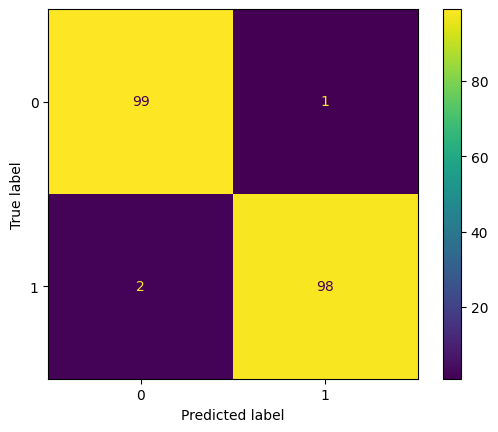

In [23]:
cm_test = confusion_matrix(y_test, y_pred_test)

ConfusionMatrixDisplay(cm_test).plot();

In [24]:
# Coefficients / model weights / parameters

coefficients_l2 = [abs(x.item()) for x in lr_l2_reg.coef_.flatten()]

coefficient_dict_l2 = dict(zip(feature_names, coefficients_l2))

coefficient_dict_l2_sorted = dict(sorted(coefficient_dict_l2.items(), key=lambda item: item[1], reverse=True))

coefficient_dict_l2_sorted

{'x6': 9.791657184075852,
 'x4': 6.732945565958953,
 'x2': 4.388864740354763,
 'x1': 4.262309107654339,
 'x5': 0.34979310374514483,
 'x3': 0.046769464438492836}

### L1-regularized Logistic Regression

In [49]:
# defining the model
# C is the inverse of regularization strength
# default solver 'lbfgs' doesn't support l1 regularization, hence using 'liblinear' as solver
lr_l1_reg = LogisticRegression(penalty='l1', C=4.0, max_iter=1000, solver='liblinear')   

# fitting / training the model
lr_l1_reg.fit(X_train, y_train)

# predicting on test dataset
y_pred_test = lr_l1_reg.predict(X_test)

c:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [50]:
# Performance on test dataset

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       100
         1.0       0.99      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



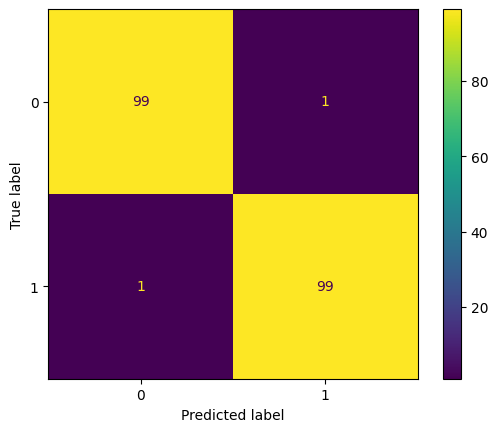

In [51]:
cm_test = confusion_matrix(y_test, y_pred_test)

ConfusionMatrixDisplay(cm_test).plot();

In [52]:
# Coefficients / model weights / parameters

coefficients_l1 = [abs(x.item()) for x in lr_l1_reg.coef_.flatten()]

coefficient_dict_l1 = dict(zip(feature_names, coefficients_l1))

coefficient_dict_l1_sorted = dict(sorted(coefficient_dict_l1.items(), key=lambda item: item[1], reverse=True))

coefficient_dict_l1_sorted

{'x6': 24.49880626469668,
 'x4': 19.393825783335572,
 'x1': 14.11486164658164,
 'x2': 6.205102703803591,
 'x5': 0.504433935110296,
 'x3': 0.0}

### ElasticNet-Regularized Logistic Regression

In [53]:
# defining the model
# C is the inverse of regularization strength
# Only the solver 'saga' support elasticnet regularization in logistic regression
lr_elasticnet_reg = LogisticRegression(penalty='elasticnet', C=3.0, l1_ratio=0.5, max_iter=1000, solver='saga')   

# fitting / training the model
lr_elasticnet_reg.fit(X_train, y_train)

# predicting on test dataset
y_pred_test = lr_elasticnet_reg.predict(X_test)

c:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [54]:
# Measuring performance on test dataset

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       100
         1.0       0.99      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



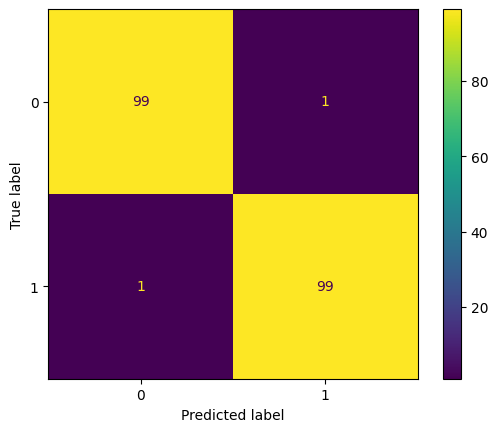

In [55]:
cm_test = confusion_matrix(y_test, y_pred_test)

ConfusionMatrixDisplay(cm_test).plot();

In [56]:
# Coefficients / model weights / parameters

coefficients_elasticnet = [abs(x.item()) for x in lr_elasticnet_reg.coef_.flatten()]

coefficient_dict_elasticnet = dict(zip(feature_names, coefficients_elasticnet))

coefficient_dict_elasticnet_sorted = dict(sorted(coefficient_dict_elasticnet.items(), key=lambda item: item[1], reverse=True))

coefficient_dict_elasticnet_sorted

{'x6': 14.416111339394345,
 'x4': 9.621376219275952,
 'x1': 7.284070174534379,
 'x2': 5.96915938646501,
 'x5': 0.314387330679953,
 'x3': 0.0}

### Comparing the coefficients (model weights) in different methods

In [58]:
coefficient_dataframe = pd.DataFrame([coefficient_dict_unreg_sorted, 
                                      coefficient_dict_l2_sorted,
                                      coefficient_dict_l1_sorted,
                                      coefficient_dict_elasticnet_sorted], 
                                      index=['Unregularized', 'L2-regularized', 'L1-regularized', 'ElasticNet']).T

coefficient_dataframe

,Unregularized,L2-regularized,L1-regularized,ElasticNet
x6,31.242136,9.791657,24.498806,14.416111
x4,21.572859,6.732946,19.393826,9.621376
x1,18.373869,4.262309,14.114862,7.284070
x2,10.328239,4.388865,6.205103,5.969159
x5,1.499711,0.349793,0.504434,0.314387
x3,0.714230,0.046769,0.000000,0.000000


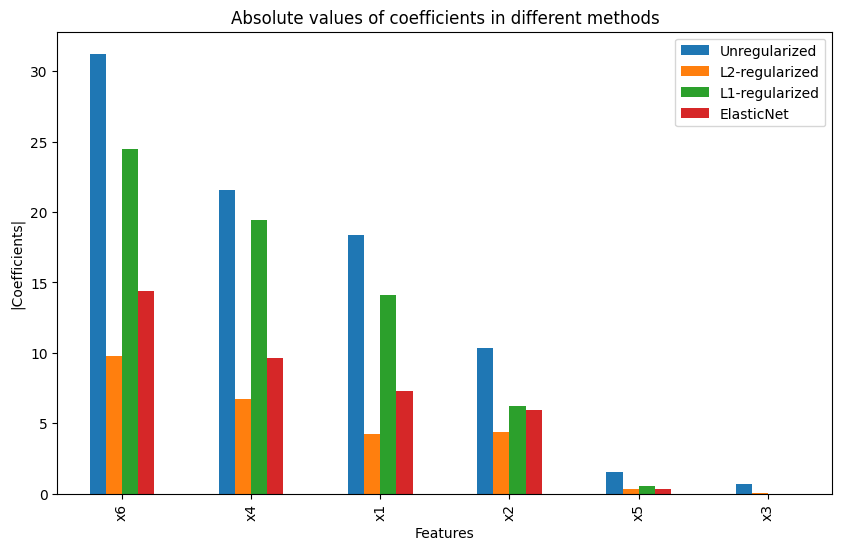

In [59]:
coefficient_dataframe.plot(kind='bar', figsize=(10,6), 
                           title="Absolute values of coefficients in different methods", 
                           xlabel="Features", ylabel="|Coefficients|")
plt.legend()
plt.show()

We can see that the performance of all the models are comparable. However, L1-regularization and ElasticNet forced some coefficients to be zero. Thereby doing feature-selection in the process.